<a href="https://colab.research.google.com/github/aabyyaann/Practical-Linear-Algebra-for-Data-Science/blob/main/Chapter13_Eigendecomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 13 — Eigendecomposition

## Tujuan Chapter

Pada chapter ini kita mempelajari salah satu konsep terpenting dalam linear algebra:

## Eigendecomposition

Topik yang akan dipelajari:

1. Eigenvalue
2. Eigenvector
3. Persamaan eigen
4. Karakteristik transformasi linear
5. Menghitung eigenvalue dan eigenvector
6. Eigendecomposition matriks
7. Rekonstruksi matriks
8. Interpretasi geometris
9. Hubungan dengan PCA
10. Aplikasi dalam machine learning

Konsep eigen merupakan fondasi dari:

- Principal Component Analysis (PCA)
- Spectral Clustering
- Markov Models
- Computer Vision
- Signal Processing
- Machine Learning

# Ringkasan Teori

Misalkan terdapat matriks:

\[
A
\]

dan vektor:

\[
v
\]

Jika transformasi matriks hanya mengubah panjang vektor tetapi tidak mengubah arah dasarnya, maka berlaku:

\[
Av=\lambda v
\]

dengan:

- \(v\) = eigenvector
- \(\lambda\) = eigenvalue

Persamaan ini disebut:

## Eigenvalue Equation

Tujuan eigendecomposition adalah memecah matriks menjadi:

\[
A=V\Lambda V^{-1}
\]

dimana:

- V berisi eigenvector
- Λ berisi eigenvalue

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# 1. Matriks Contoh

Kita mulai dengan matriks sederhana.

In [2]:
A = np.array([
    [3.,1.],
    [1.,3.]
])

print(A)

[[3. 1.]
 [1. 3.]]


# 2. Menghitung Eigenvalue dan Eigenvector

NumPy menyediakan fungsi:

```python
np.linalg.eig()
```

untuk menghitung eigenvalue dan eigenvector.

In [3]:
eigvals, eigvecs = np.linalg.eig(A)

print("Eigenvalues:")
print(eigvals)

print("\nEigenvectors:")
print(eigvecs)

Eigenvalues:
[4. 2.]

Eigenvectors:
[[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]


# Interpretasi

Output menghasilkan:

- daftar eigenvalue
- matriks eigenvector

Setiap kolom pada matriks eigenvector merupakan sebuah eigenvector.

In [4]:
for i in range(len(eigvals)):
    print(f"Eigenvalue {i+1}:")
    print(eigvals[i])

    print("Eigenvector:")
    print(eigvecs[:,i])

    print()

Eigenvalue 1:
4.0
Eigenvector:
[0.7071 0.7071]

Eigenvalue 2:
2.0
Eigenvector:
[-0.7071  0.7071]



# 3. Verifikasi Persamaan Eigen

Kita akan memverifikasi:

\[
Av=\lambda v
\]

In [5]:
v = eigvecs[:,0]
lam = eigvals[0]

left = A @ v
right = lam * v

print("Av =")
print(left)

print("\nλv =")
print(right)

Av =
[2.8284 2.8284]

λv =
[2.8284 2.8284]


# Hasil

Jika kedua vektor identik (atau sangat dekat secara numerik), maka vektor tersebut benar-benar eigenvector dari matriks A.

In [6]:
np.allclose(left,right)

True

# 4. Visualisasi Eigenvector

Kita visualisasikan eigenvector pada bidang 2D.

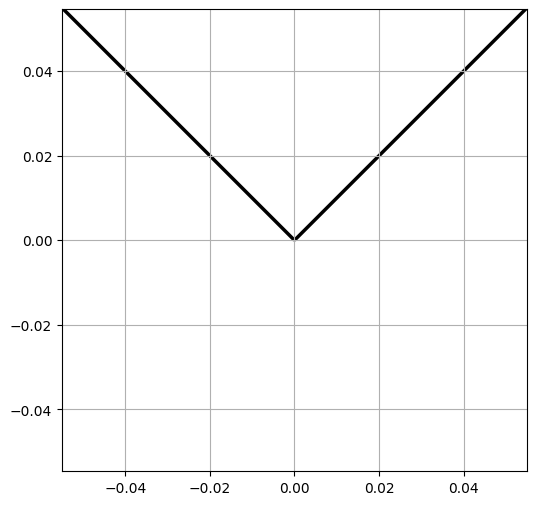

In [7]:
plt.figure(figsize=(6,6))

origin = [0,0]

for i in range(2):
    vec = eigvecs[:,i]

    plt.quiver(
        *origin,
        vec[0],
        vec[1],
        angles='xy',
        scale_units='xy',
        scale=1
    )

plt.xlim(-1.5,1.5)
plt.ylim(-1.5,1.5)

plt.grid(True)
plt.axis('equal')
plt.show()

# 5. Transformasi Eigenvector

Ketika matriks A diterapkan ke eigenvector, arah dasarnya tetap sama.

Yang berubah hanyalah skalanya sesuai eigenvalue.

In [8]:
v = eigvecs[:,0]

Av = A @ v

print("v =")
print(v)

print("\nAv =")
print(Av)

v =
[0.7071 0.7071]

Av =
[2.8284 2.8284]


# 6. Eigenvalue Positif dan Negatif

Interpretasi eigenvalue:

### λ > 1
vektor diperbesar

### 0 < λ < 1
vektor diperkecil

### λ < 0
vektor dibalik arah dan diskalakan

### λ = 0
vektor dipetakan menjadi nol

In [9]:
lambda_examples = [3,0.5,-2,0]

for l in lambda_examples:
    print(f"Eigenvalue = {l}")

Eigenvalue = 3
Eigenvalue = 0.5
Eigenvalue = -2
Eigenvalue = 0


# 7. Matriks Diagonal

Matriks diagonal memiliki eigenvalue yang sangat mudah dihitung.

Nilai diagonalnya langsung menjadi eigenvalue.

In [10]:
D = np.array([
    [5.,0.],
    [0.,2.]
])

eigvals_D, eigvecs_D = np.linalg.eig(D)

print("Eigenvalues:")
print(eigvals_D)

Eigenvalues:
[5. 2.]


# Penjelasan

Untuk matriks diagonal:

\[
D=
\begin{bmatrix}
5 & 0\\
0 & 2
\end{bmatrix}
\]

eigenvalue langsung:

\[
5, 2
\]

# 8. Eigendecomposition

Tujuan utama chapter ini adalah menuliskan:

\[
A=V\Lambda V^{-1}
\]

dengan:

- V = matriks eigenvector
- Λ = matriks diagonal eigenvalue

In [11]:
V = eigvecs

Lambda = np.diag(eigvals)

print("V =")
print(V)

print("\nLambda =")
print(Lambda)

V =
[[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]

Lambda =
[[4. 0.]
 [0. 2.]]


In [12]:
A_reconstructed = V @ Lambda @ np.linalg.inv(V)

print(A_reconstructed)

[[3. 1.]
 [1. 3.]]


# Verifikasi Rekonstruksi

In [13]:
np.allclose(A,A_reconstructed)

True

# Hasil

Kita berhasil membangun kembali matriks asli menggunakan eigendecomposition.

# 9. Mengapa Eigendecomposition Penting?

Banyak operasi matriks menjadi jauh lebih mudah setelah matriks diuraikan menjadi:

\[
V\Lambda V^{-1}
\]

Misalnya:

\[
A^n
\]

menjadi:

\[
A^n = V\Lambda^nV^{-1}
\]

In [14]:
n = 5

A_power = np.linalg.matrix_power(A,n)

print(A_power)

[[528. 496.]
 [496. 528.]]


In [15]:
Lambda_power = np.diag(eigvals**n)

A_power_eig = (
    V @
    Lambda_power @
    np.linalg.inv(V)
)

print(A_power_eig)

[[528. 496.]
 [496. 528.]]


# Verifikasi

In [16]:
np.allclose(
    A_power,
    A_power_eig
)

True

# 10. Matriks Simetris

Matriks simetris memenuhi:

\[
A=A^T
\]

Matriks simetris memiliki sifat sangat penting:

- seluruh eigenvalue real
- eigenvector saling orthogonal

In [17]:
S = np.array([
    [4.,1.,2.],
    [1.,3.,0.],
    [2.,0.,5.]
])

print(np.allclose(S,S.T))

True


In [18]:
eigvals_S, eigvecs_S = np.linalg.eig(S)

print(eigvals_S)

[6.6691 1.8549 3.476 ]


# 11. Orthogonal Eigenvectors

In [19]:
v1 = eigvecs_S[:,0]
v2 = eigvecs_S[:,1]

dot = np.dot(v1,v2)

print(dot)

1.6653345369377348e-16


# Interpretasi

Nilai dot product yang mendekati nol menunjukkan kedua eigenvector orthogonal.

# 12. Hubungan dengan PCA

Principal Component Analysis (PCA) bekerja dengan:

1. menghitung covariance matrix
2. mencari eigenvalue
3. mencari eigenvector
4. memilih eigenvalue terbesar

Eigenvector terbesar menjadi principal components.

In [20]:
X = np.array([
    [2,1],
    [3,2],
    [4,3],
    [5,4],
    [6,5]
])

X_centered = X - np.mean(X,axis=0)

cov = np.cov(
    X_centered.T
)

print(cov)

[[2.5 2.5]
 [2.5 2.5]]


In [21]:
eigvals_cov, eigvecs_cov = np.linalg.eig(cov)

print("Eigenvalues:")
print(eigvals_cov)

print("\nEigenvectors:")
print(eigvecs_cov)

Eigenvalues:
[5. 0.]

Eigenvectors:
[[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]


# Interpretasi PCA

Eigenvalue terbesar menunjukkan arah dengan variasi data terbesar.

Arah tersebut dipilih sebagai principal component pertama.

In [22]:
largest_idx = np.argmax(eigvals_cov)

pc1 = eigvecs_cov[:,largest_idx]

print(pc1)

[0.7071 0.7071]


# 13. Aplikasi Eigenvalue dan Eigenvector

Konsep eigen digunakan pada:

- PCA
- Face Recognition
- Recommendation Systems
- Image Compression
- Spectral Clustering
- Network Analysis
- Quantum Mechanics
- Signal Processing

# Ringkasan Chapter 13

Pada chapter ini kita mempelajari:

- Eigenvalue
- Eigenvector
- Persamaan Eigen
- Eigendecomposition
- Rekonstruksi Matriks
- Matrix Powers
- Matriks Simetris
- Orthogonal Eigenvectors
- PCA Dasar

Eigendecomposition merupakan salah satu konsep paling penting dalam linear algebra modern dan menjadi fondasi berbagai algoritma machine learning dan data science.